Imports and environment variables

In [53]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import norm

Introduction - META stock price extraction and plot

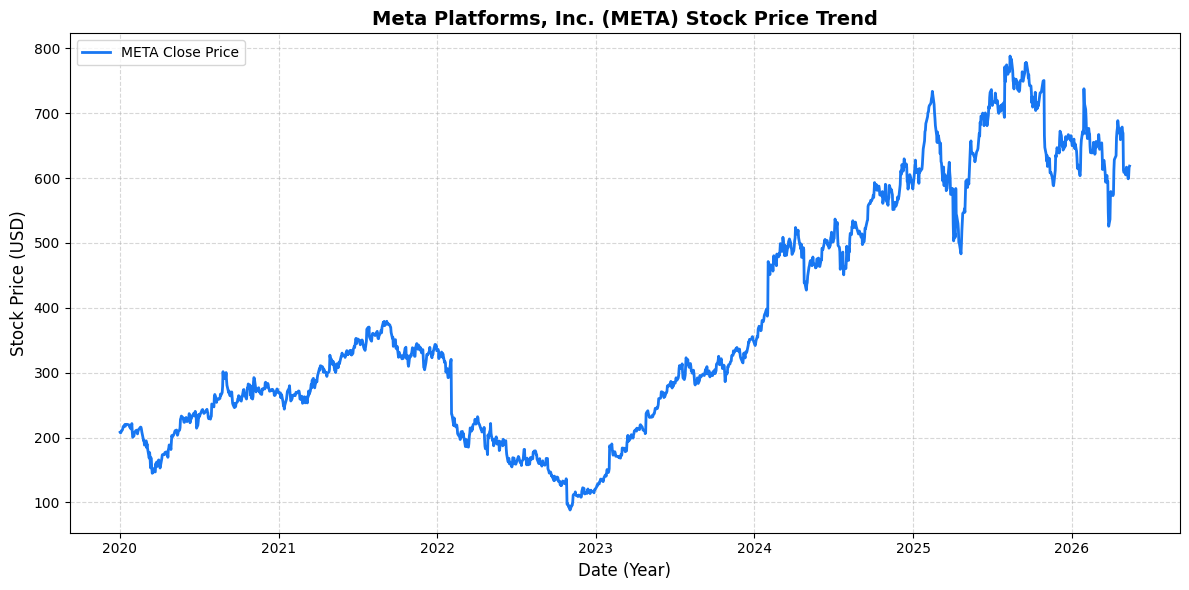

In [54]:
meta = yf.Ticker("META")
meta_intro_df = meta.history(start="2020-01-01", end="2026-05-15")

# Plot of META stock price
plt.figure(figsize=(12, 6))
plt.plot(meta_intro_df.index, meta_intro_df['Close'], color='#1877F2', linewidth=2, label='META Close Price')

plt.title('Meta Platforms, Inc. (META) Stock Price Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date (Year)', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.legend()

plt.savefig(
    "../figures/meta_close_price.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Black-Scholes Simulation of the META stock since 2020

[*********************100%***********************]  1 of 1 completed


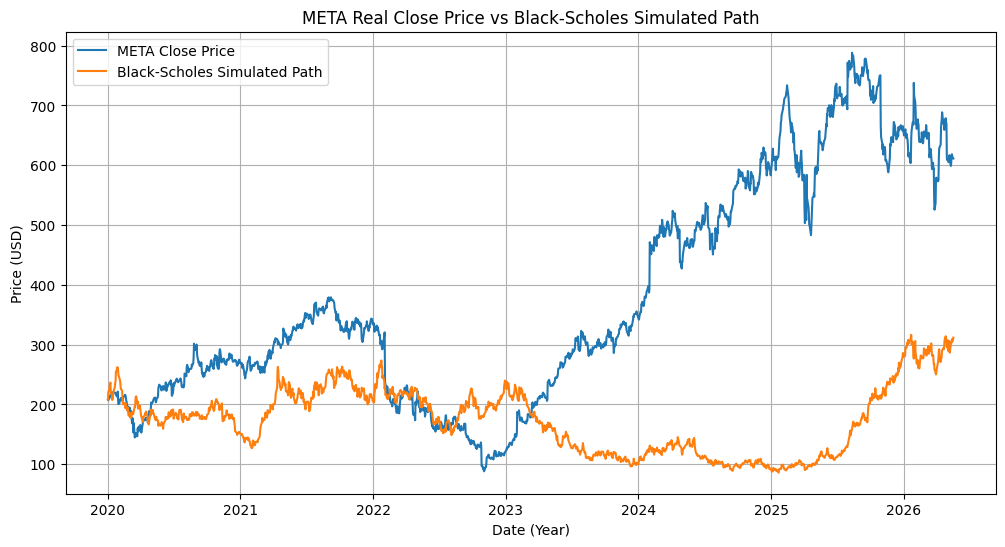

In [86]:
meta = yf.download("META", start="2020-01-01")

prices = meta['Close']['META']
log_returns = np.log(prices / prices.shift(1))
mu = float(log_returns.mean() * 252) 
sigma = float(log_returns.std() * np.sqrt(252))

# Time grid
N = len(prices)
T = N / 252
dt = 1 / 252

# BS data frame
S0 = float(prices.iloc[0])
S_sim = [S0]

# Compute d1 and d2 over time
for t in range(1,N):
    Z = np.random.normal()
    S_next = S_sim[-1]*np.exp((mu-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z)
    S_sim.append(S_next)


plt.figure(figsize=(12, 6))
plt.plot(meta.index, prices, label="META Close Price")
plt.plot(meta.index, S_sim, label="Black-Scholes Simulated Path")

plt.xlabel("Date (Year)")
plt.ylabel("Price (USD)")
plt.title("META Real Close Price vs Black-Scholes Simulated Path")
plt.legend()
plt.grid(True)
plt.savefig(
    "../figures/meta_close_price_vs_BS_path.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()